In [1]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fontsize = 14
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": fontsize,
    #'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents}',
    'figure.dpi': 200
})

In [3]:
from typing import Dict, Tuple, Optional

def get_last_file(path: Path) -> Path | None:
    # --- Step 1: Look for final files first ---
    final_candidates = [
        path / "TR_IRGNM_final.pkl",
        path / "FOM_IRGNM_final.pkl"
    ]
    
    for final_file in final_candidates:
        if final_file.exists():
            return final_file.name  # Return immediately if found
    
    # --- Step 2: If no final file exists, find the highest index file ---
    files = glob.glob(os.path.join(path, "TR_IRGNM_*.pkl"))
    files += glob.glob(os.path.join(path, "FOM_IRGNM_*.pkl"))

    indexed_files = []
    for f in files:
        match = re.search(r'(?:TR|FOM)_IRGNM_(\d+)\.pkl$', os.path.basename(f))
        if match:
            idx = int(match.group(1))
            indexed_files.append((idx, f))

    if indexed_files:
        _, max_file = max(indexed_files, key=lambda x: x[0])
        return Path(max_file).name

    print("No matching IRGNM result files found.")
    return None

def filter_and_reorder(d: Dict, pattern: str = r'.*FOM.*') -> Tuple[Dict, Optional[str]]:
    regex = re.compile(pattern)
    matching = [k for k in d if regex.search(k)]
    non_matching = [k for k in d if k not in matching]

    # Sort keys alphabetically within each group
    non_matching_sorted = sorted(non_matching)
    matching_sorted = sorted(matching)

    # Build the reordered dict: alphabetically sorted non-matching first, then matching ones
    reordered = {k: d[k] for k in non_matching_sorted}
    reordered.update({k: d[k] for k in matching_sorted})

    # Return reordered dict and the single matching key (if exactly one match)
    if len(matching_sorted) == 1:
        return reordered, matching_sorted[0]
    else:
        return reordered, None

In [4]:
#SAVE_PATH = Path('/home/dealii/workdir/figs')
SAVE_PATH = Path('/home/benedikt/Schreibtisch/error_stagnation')

########################################################################################

WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
#WORK_DIR = Path('/home/dealii/workdir/experiments')
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')

subset = 'log_errors'
obs_op = 'sensors'
data_dir_path = WORK_DIR / 'log_errors_' 

experiment_names = []
pattern = re.compile(rf'^{subset}_.*_{obs_op}.*')

experiment_names += [
    d.name for d in data_dir_path.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

data_paths = [data_dir_path / experiment_name for experiment_name in experiment_names]
file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

# #data_dir_path = Path('/home/dealii/workdir/examples/elasticity/dumps') / '20251201_121655_TR_IRGNM'
# data_dir_path = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/examples/elasticity/dumps') / '20251201_162724_TR_IRGNM'

# experiment_names = []
# pattern = re.compile(rf'.*')

# experiment_names += [
#     d.name for d in data_dir_path.iterdir()
#     if d.is_dir() and pattern.match(d.name)
# ]

# data_paths = [data_dir_path]
#file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

setup = None
data = {}
optimizer_parameters = {}

for (data_path, file_name) in zip(data_paths, file_names):            

    try:
        with open(data_path / file_name, 'rb') as file:
            data_ = load(file)
        data[str(data_path.name)] = data_
    except TypeError:
        print(f"Can not find dumps for {data_path}")
    except:
        print(f"Can not open {data_path / file_name}")

    if not setup:
        with open(data_path / 'setup.pkl', 'rb') as file:
            setup = load(file)

    
    optimizer_parameter_path = data_path / 'optimizer_parameter.pkl'
    with open(optimizer_parameter_path, 'rb') as file:
        optimizer_parameter = load(file)
        
    optimizer_parameters[str(data_path.name)] = optimizer_parameter

data, FOM_key = filter_and_reorder(data, pattern=r'.*FOM.*')
#assert FOM_key

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)

print(data.keys())


dict_keys(['log_errors_TR_sensors_0.001', 'log_errors_TR_sensors_0.001_include_lins', 'log_errors_TR_sensors_1e-06', 'log_errors_TR_sensors_1e-09', 'log_errors_TR_sensors_1e-12'])


In [6]:
from RBInvParam.reductor import InstationaryModelIPReductor

FOM = build_InstationaryModelIP(setup=setup)
reductor = InstationaryModelIPReductor(
    FOM,
    optimizer_parameter['error_estimator_types'],
    use_adjoint_space = optimizer_parameter["use_adjoint_space"],
    parallel = optimizer_parameter["offline_parallel"]
)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

[2025-12-02 16:53:32,240][build_InstationaryModelIP] - Construct problem..
	 Setting up BC constraints.
	 Setting up system matrizies.
	 Using CosseratDelamination SystemMatrix
	 Using CenterExcite BodyForce
	 Assembling force list.
	 ---------------------- 
	 #DoFs: 14415
	 #Parameter: 961


KeyboardInterrupt: 

In [ ]:
from RBInvParam.reductor import InstationaryModelIPReductor
from RBInvParam.snapshot_preprocessor import SnapshotPreprocessor

import pymor_dealii_bindings as pd2

data_ = data['log_errors_TR_sensors_1e-09']
bases = ['parameter_basis', 'state_basis']

reductor = InstationaryModelIPReductor(
    FOM,
    optimizer_parameter['error_estimator_types'],
    use_adjoint_space = optimizer_parameter["use_adjoint_space"],
    parallel = optimizer_parameter["offline_parallel"]
)

snapshot_preprocessor = SnapshotPreprocessor(
    FOM = FOM
)

enrichment = {
    'parameter_basis' : {
        'compression' : {
            # 'normalize' : True,
            # 'HaPOD' : {
            #     'eps': 1e-6,
            #     'omega' : 0.1,
            # }
            'normalize' : None,
            'HaPOD' : None
        }
    },
    'state_basis' : {
        'compression' : {
            # 'normalize' : True,
            # 'HaPOD' : {
            #     'eps': 1e-9,
            #     'omega' : 0.1,
            # }
            'normalize' : None,
            'HaPOD' : None
        }        
    }
}

#parameter_snapshots = data_['snapshots']['parameter_basis'].to_numpy()[0:200]
state_snapshots = data_['snapshots']['state_basis'].to_numpy()[0:200]

parameter_snapshots = FOM.Q.empty()
for i in range(len(data_['q'])):
    parameter_snapshots.append(data_['q'][i])
    
parameter_snapshots = parameter_snapshots.to_numpy()

#state_snapshots = FOM.solve_state(q = data_['q'][0]).to_numpy()

for basis in bases:
    if basis == 'parameter_basis':
        snapshots = FOM.Q.make_array(parameter_snapshots)
    else:
        snapshots = FOM.V.empty()
        for i in range(state_snapshots.shape[0]):
            snapshots.append(
                FOM.V.make_array([FOM.V.real_vector_from_numpy(state_snapshots[i])])
            )
            
    snapshots = snapshot_preprocessor.preprocess(
        snapshots = snapshots,
        product = reductor.products[basis],
        config = enrichment[basis]['compression']
    )
    
    reductor.extend_basis(
        U = snapshots,
        basis = basis
    )

reductor.dims_history['parameter_basis'].append(reductor.get_bases_dim('parameter_basis'))
reductor.dims_history['state_basis'].append(reductor.get_bases_dim('state_basis'))
reductor.dims_history['adjoint_basis'].append(reductor.get_bases_dim('adjoint_basis'))

print(f"Dim Qr-space = {reductor.get_bases_dim('parameter_basis')}")
print(f"Dim Vr-space = {reductor.get_bases_dim('state_basis')}")
print(f"Dim Wr-space = {reductor.get_bases_dim('adjoint_basis')}")


QrVrROM = reductor.reduce()

In [7]:
# u_r = QrVrROM.solve_state(q=QrVrROM.Q.make_array(reductor.project_vectorarray(data_['q'][0], basis='parameter_basis')))
# u_h = FOM.solve_state(q=data_['q'][0])
# print(np.max(np.abs(u_h.to_numpy() - reductor.reconstruct(u_r, basis='state_basis').to_numpy())))
# q_ = reductor.project_vectorarray(data_['q'][0], basis='parameter_basis')
# q_ = QrVrROM.Q.make_array(q_)

# ret = optimizer._calc_errors(
#     model = QrVrROM,
#     reductor=reductor,
#     q_r = q_,
#     targets = ['J']
# )
# print(ret['err_u'])

In [ ]:
from RBInvParam.optimizer import QrVrROMOptimizer

optimizer = QrVrROMOptimizer(
        FOM = FOM,
        optimizer_parameter = optimizer_parameter,
        save_path='./'
    )

In [ ]:
data_ = data['log_errors_TR_sensors_1e-09']
errors = {}
##############################################

# q_test = np.random.uniform(0.75, 3, size=(10, FOM.Q.dim))
# q_test = FOM.Q.make_array(q_test)

##############################################

# q_test_ = data_['q']
# noise = np.random.uniform(-1e-2, 1e-2, size=(len(q_test), FOM.Q.dim))

# q_test = []
# for q, n in zip(q_test_, noise):
#     q_test.append(q)        # original
#     q_test.append(q + FOM.Q.make_array(n))    # noisy copy

# res_q = 2

##############################################
#res_q = 1
res_q = 5


q_test = []
for i in range(len(data_['q']) - 1):
    d = data_['q'][i+1] - data_['q'][i]    
    #norm_d = np.sqrt(FOM.products['prod_Q'].apply2(d, d))
    #print(norm_d)

    for j in range(res_q):
        t = j / (res_q + 1)
        q_test.append(data_['q'][i] + d * t)

q_test.append(data_['q'][-1])

##############################################
#targets = ['J']
targets = ['J', 'nabla_J']

for i, q in enumerate(q_test):
    if i % 5 == 0:
        print(f"{i} / {len(q_test)}")

    q_ = reductor.project_vectorarray(q, basis='parameter_basis')
    q_ = QrVrROM.Q.make_array(q_)

    ret = optimizer._calc_errors(
        model = QrVrROM,
        reductor=reductor,
        q_r = q_,
        targets = targets 
    )

    for key in ret.keys():
        if key not in errors.keys():
            errors[key] = [ret[key]]
        else:
            errors[key].append(ret[key])
    
    # u_h = FOM.solve_state(q=q)

    # q_ = reductor.project_vectorarray(q, basis='parameter_basis')
    # q_ = QrVrROM.Q.make_array(q_)
    # u_r = QrVrROM.solve_state(q=q_)
    # u_r = reductor.reconstruct(u_r, basis='state_basis')

    # diff = u_h - u_r
    # err_u = np.sqrt(FOM.products['bochner_prod_V'].apply2(diff, diff))[0,0]
    # err_us.append(err_u)
    
#print(errors)

0 / 61


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

5 / 61
10 / 61
15 / 61


/tmp/ipykernel_14539/2806659733.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


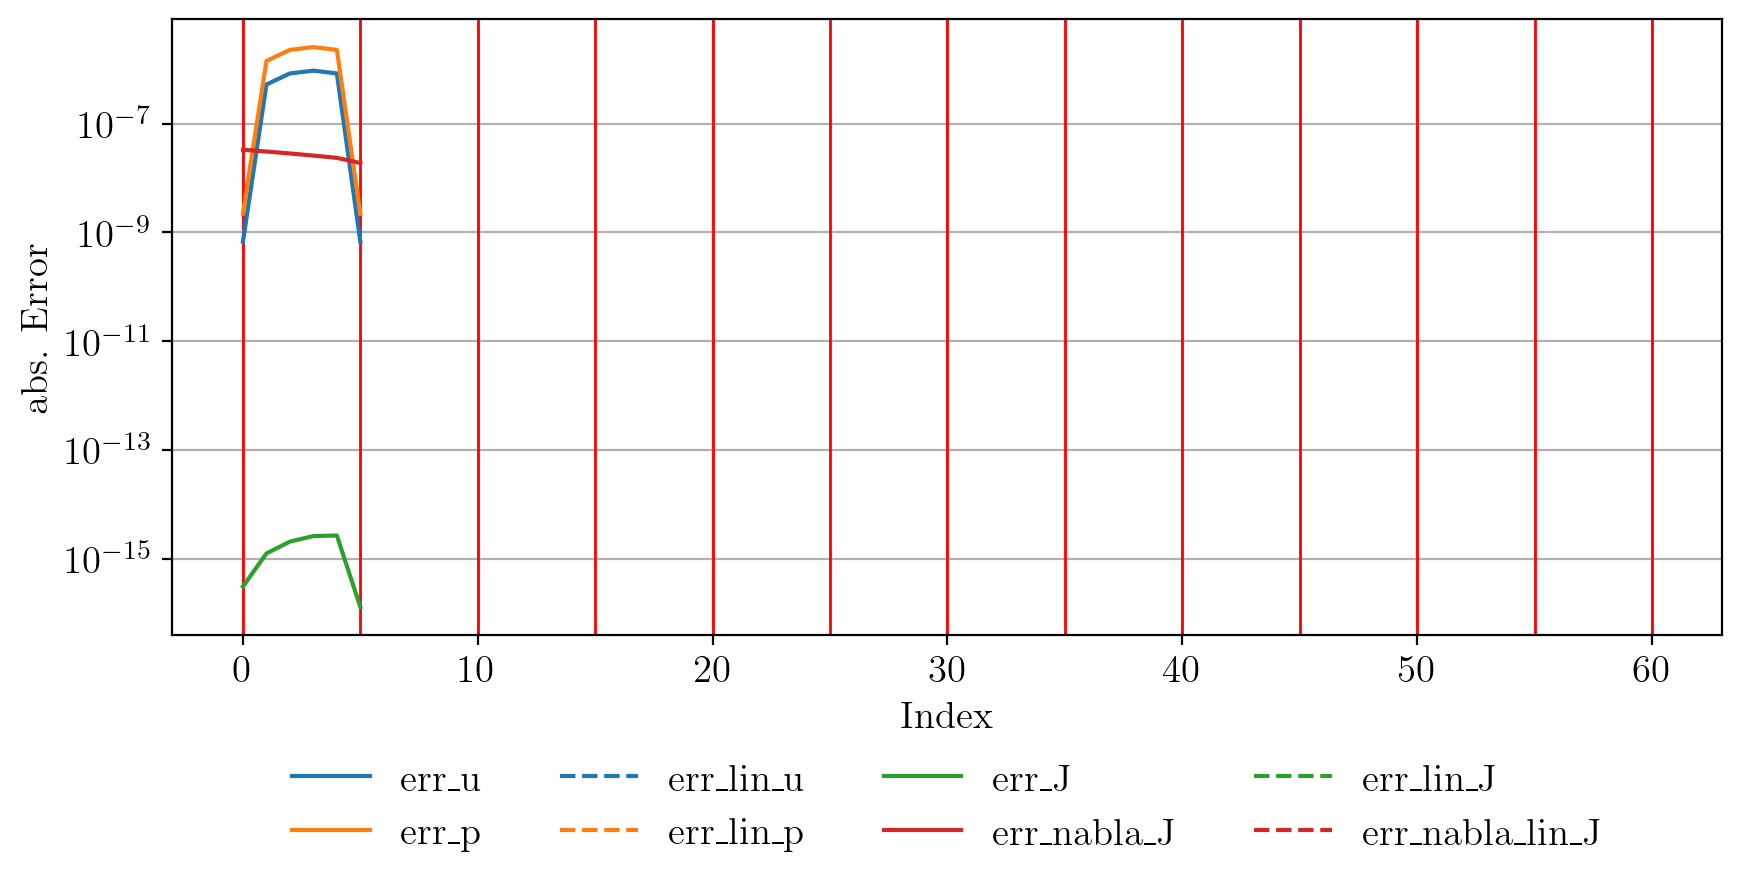

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

cmap = plt.cm.get_cmap('tab10')
colors = cmap.colors

colors = {
    'err_u'            : colors[0], 
    'err_p'            : colors[1], 
    'err_lin_u'        : colors[0],
    'err_lin_p'        : colors[1], 
    'err_J'            : colors[2], 
    'err_nabla_J'      : colors[3], 
    'err_lin_J'        : colors[2], 
    'err_nabla_lin_J'  : colors[3]
}

linestyles = {
    'err_u'            : '-', 
    'err_p'            : '-', 
    'err_lin_u'        : '--', 
    'err_lin_p'        : '--', 
    'err_J'            : '-',
    'err_nabla_J'      : '-', 
    'err_lin_J'        : '--',
    'err_nabla_lin_J'  : '--',
}


for i in range(len(q_test) + 1):
    if i % res_q == 0:
        ax.axvline(i, color='red', linewidth=1)

# Optional: show something plotted for context
for key, values in errors.items():
    if not key.startswith("rel_"):
        plt.plot(values, label=key, color=colors[key], linestyle=linestyles[key])

ax.set_xlabel("Index")
ax.set_ylabel("abs. Error")
ax.grid(True)
ax.set_yscale('log')
ax.legend()

handles, labels = plt.gca().get_legend_handles_labels()   # <<< FIXED
plt.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    frameon=False,
    fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.15)  # place below
)

#plt.show()
#plt.savefig(SAVE_PATH / Path(f'post_proc_abs_error_200_None_400_None_p.pdf'), bbox_inches="tight")
plt.savefig(SAVE_PATH / Path(f'interpol_params_post_proc_abs_error_400_None_all_full.pdf'), bbox_inches="tight")


/tmp/ipykernel_112757/3643029050.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


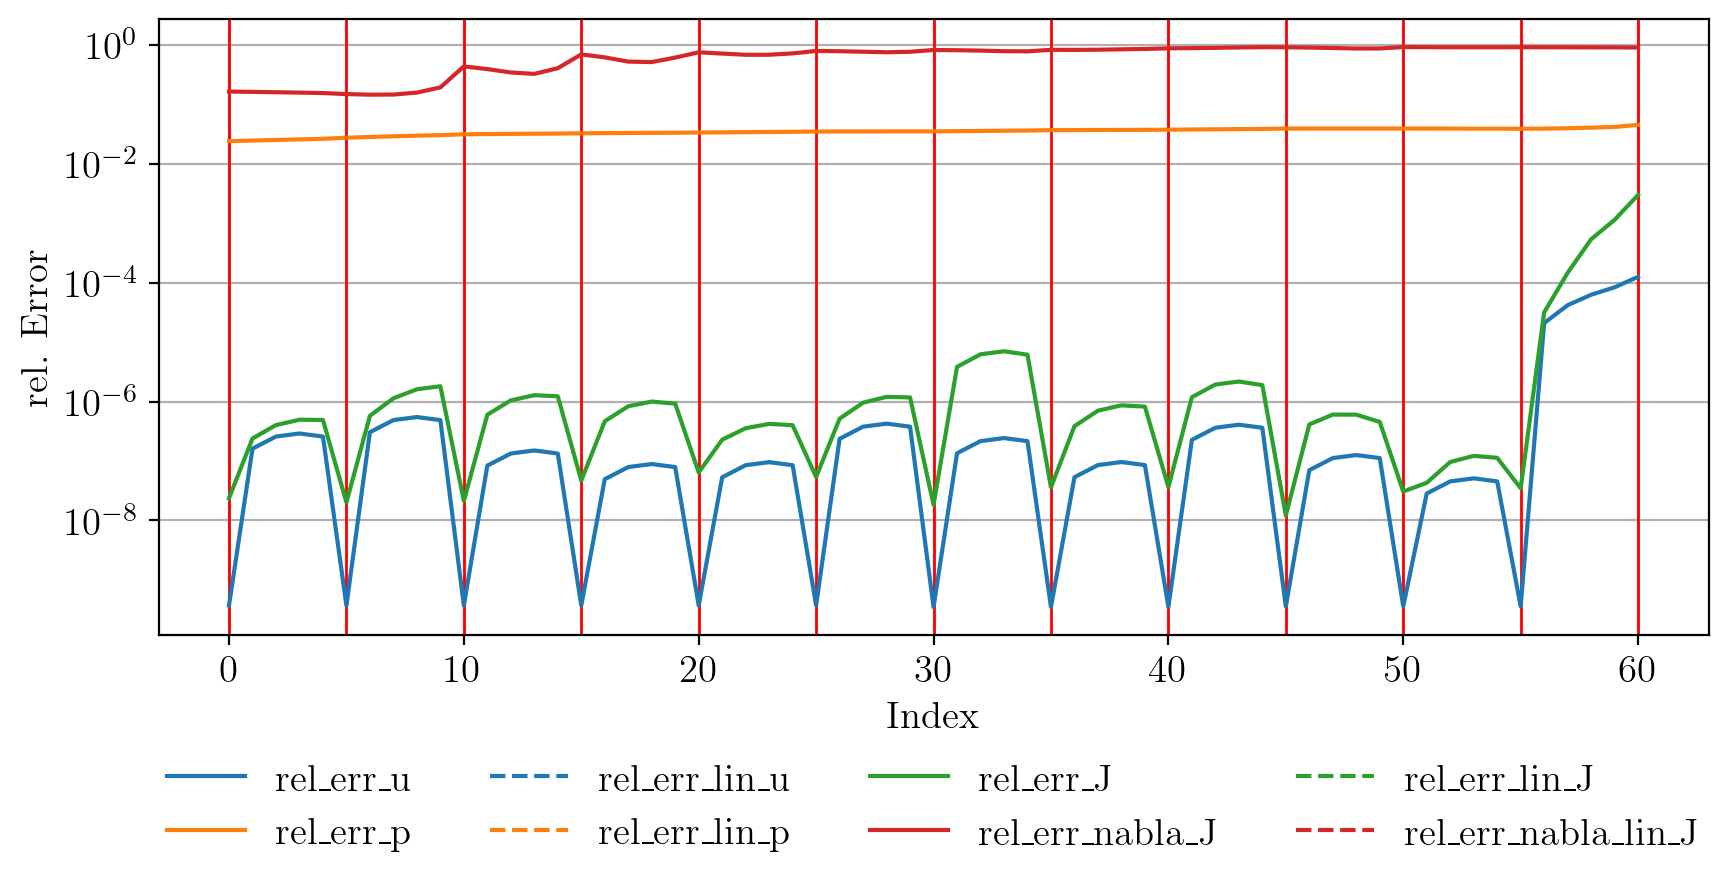

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

cmap = plt.cm.get_cmap('tab10')
colors = cmap.colors

colors = {
    'rel_err_u' : colors[0], 
    'rel_err_p' : colors[1], 
    'rel_err_lin_u' : colors[0],
    'rel_err_lin_p' : colors[1], 
    'rel_err_J' : colors[2], 
    'rel_err_nabla_J' : colors[3], 
    'rel_err_lin_J' : colors[2], 
    'rel_err_nabla_lin_J' : colors[3]
}

linestyles = {
    'rel_err_u' : '-', 
    'rel_err_p' : '-', 
    'rel_err_lin_u' : '--', 
    'rel_err_lin_p' : '--', 
    'rel_err_J' : '-',
    'rel_err_nabla_J' : '-', 
    'rel_err_lin_J' : '--',
    'rel_err_nabla_lin_J' : '--',
}


for i in range(len(q_test) + 1):
    if i % res_q == 0:
        ax.axvline(i, color='red', linewidth=1)

# Optional: show something plotted for context
for key, values in errors.items():
    if key.startswith("rel_"):
        plt.plot(values, label=key, color=colors[key], linestyle=linestyles[key])
ax.set_xlabel("Index")
ax.set_ylabel("rel. Error")
ax.grid(True)
ax.set_yscale('log')
ax.legend()

handles, labels = plt.gca().get_legend_handles_labels()   # <<< FIXED
plt.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    frameon=False,
    fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.15)  # place below
)


#plt.show()
#plt.savefig(SAVE_PATH / Path(f'post_proc_rel_error_200_1e-1_400_1e-6.pdf'), bbox_inches="tight")
plt.savefig(SAVE_PATH / Path(f'interpol_params_post_proc_rel_error_400_None_all_full.pdf'), bbox_inches="tight")
